# NIR PIPELINE FROM SCRATCH

This notebook is for learning how to process/analyze nir data, syncing, etc. <br>
And to perform new analyses/processing steps when needed

---

For actually processing NIR data, use ANTSUN ::
    [Instructions here](https://github.com/flavell-lab/FlavellLabWiki/wiki/Setting-up-the-ANTSUN-pipeline)

Summary of instructions:
- start apptainer
- source bashrc
- start jupyterlab

# TODO

- pos_feature, shape=(12927, 3, 3), x,y,confidence of 3 deeplabcut labeled features on the head of the worm, for each saved frame
    - can use them to estimate 'jitter'/high frequency noise in stage pos, perform a low pass filter to get rid of it
- vel_x, vel_y, speed (1s mov avg)

- need to 'orient' nir segmentation:
    - head and tail
    - dorsal and ventral


- finish behavior:

    - get_body_angles!(data_dict, param) (DONE)
    - get_angular_velocity!(data_dict, param) 
    - get_velocity!(data_dict, param)
    - get_curvature_variables!(data_dict, param)
    - get_nose_curling!(data_dict, param);



## IMPORTS

In [ ]:

import sys
import os
import importlib
import pickle
from tqdm import tqdm
from pathlib import Path
from datetime import datetime
import shutil
import pandas as pd
import h5py
import numpy as np
import utils
import nir_utils
from scipy.stats import mode
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
import plot_utils
plot_utils.default_plt_params()

## CONSTANTS

In [ ]:
NIDAQ_SAMPLE_RATE_AI = 5000.0 # Hz
CONTROL_NIR_FPS = 40.0
SAVE_NIR_FPS = 20.0

FLIR_BFS_PIX_SIZE = 1 / 791 # [mm/px] 

STAGE_UNIT = 10000 # stage unit / mm

IMG_SIZE_X = 968
IMG_SIZE_Y = 732

## SPECIFY DATA TO PROCESS

In [ ]:
data_dir = r'/store1/shared/g5ht/data' # this is a linux machine

# dataset (see datasets.txt)
dataset = 'date-20251028_time-1500_strain-ISg5HT_condition-starvedpatch_worm001.h5'

LOAD DATA

In [ ]:

# directories and paths

INPUT_H5 = dataset
date_str = INPUT_H5.split('_')[0].split('-')[1]
local_dir = os.path.join(data_dir, date_str)
os.makedirs(local_dir, exist_ok=True)
INPUT_H5_PTH = os.path.join(local_dir, INPUT_H5)


OUT_DIR = utils.get_output_dir(INPUT_H5_PTH)
EIG_PATH = os.path.join(OUT_DIR, 'nir_eigenworms.h5')
SYNC_PATH = os.path.join(OUT_DIR, 'sync_results.pkl')


# load h5 file
if os.path.exists(INPUT_H5_PTH):
    print(f"Loading HDF5 file: {INPUT_H5_PTH}")
    with h5py.File(INPUT_H5_PTH, 'r') as f:
        daqmx_ai = f['daqmx_ai'][:]
        daqmx_di = f['daqmx_di'][:]
        n_img_nir = f['img_nir'].shape[0]
        img_metadata = f['img_metadata']
        img_timestamp = img_metadata['img_timestamp'][:]
        img_id = img_metadata["img_id"][:]
        q_iter_save = img_metadata["q_iter_save"][:]
        pos_stage = f['pos_stage'][:] / STAGE_UNIT # (samples, [x,y]) in mm
        pos_feature = f['pos_feature'][:]  # (samples, [x,y,conf], feature)
        # img_nir = nir_utils.load_img_nir(INPUT_H5_PTH) # loads all frames (samples, H, W)
        print("HDF5 file loaded successfully.")
        print("HDF5 file structure:")
    nir_utils.print_h5_structure(INPUT_H5_PTH)

## DLC FEATURES

will use them to estimate high frequency jitter in stage pos since stage uses these points to move

In [ ]:
img_nir = nir_utils.load_img_nir(INPUT_H5_PTH, frames=[200,300])

print(img_nir.shape)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(img_nir[0], cmap='gray', vmin=0, vmax=255)
ax[1].imshow(img_nir[1], cmap='gray', vmin=0, vmax=255)
ax[0].set_title('frame 200')
ax[1].set_title('frame 300')

# overlay frame img with features
color_map = plt.get_cmap('tab10') # get a color map with 10 distinct colors
for i in range(pos_feature.shape[2]): # loop over features
    ax[0].scatter(pos_feature[200, 0, i], pos_feature[200, 1, i], label=f'Feature {i}', s=50, facecolors=color_map(i), edgecolors=color_map(i))
    ax[1].scatter(pos_feature[300, 0, i], pos_feature[300, 1, i], label=f'Feature {i}', s=50, facecolors=color_map(i), edgecolors=color_map(i))

plt.tight_layout()
plt.show()


## STAGE POS

In [ ]:
min_lim = np.nanmin(pos_stage) - 0.1
max_lim = np.nanmax(pos_stage) + 0.1

# interpolate missing values
def interpolate_nan_values(arr):
    """Interpolate NaN values in a 2D array."""
    for i in range(arr.shape[1]):
        col = arr[:, i]
        nans = np.isnan(col)
        if np.any(nans):
            not_nans = ~nans
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nans), col[not_nans])
    return arr
pos_stage_interp = interpolate_nan_values(pos_stage)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(pos_stage_interp[:,0], pos_stage_interp[:,1], label='Stage Position', color='steelblue')
ax.set_xlabel('X Position (mm)')
ax.set_ylabel('Y Position (mm)')
# ax.set_xlim(min_lim, max_lim)
# ax.set_ylim(min_lim, max_lim)
plt.tight_layout()
plt.show()


## SYNC

In [ ]:
# load h5 file and print structures
with h5py.File(INPUT_H5_PTH, 'r') as f:
    daqmx_ai = f['daqmx_ai'][:]
    daqmx_di = f['daqmx_di'][:]
    n_img_nir = f['img_nir'].shape[0]
    img_metadata = f['img_metadata']
    img_timestamp = img_metadata['img_timestamp'][:]
    img_id = img_metadata["img_id"][:]
    q_iter_save = img_metadata["q_iter_save"][:].astype(bool)
        
print(f"Loaded daqmx_ai with shape: {daqmx_ai.shape}")
print(f"Loaded daqmx_di with shape: {daqmx_di.shape}")
print(f"img_id with shape: {img_id.shape}")
print(f"img_timestamp with shape: {img_timestamp.shape}")
print(f"q_iter_save with shape: {q_iter_save.shape}")
print(f"Number of NIR images: {n_img_nir}")

di_confocal = daqmx_di[0,:].astype(np.float32)
di_nir = daqmx_di[1,:].astype(np.float32)
ai_laser = daqmx_ai[0,:].astype(np.float32)
ai_piezo = daqmx_ai[1,:].astype(np.float32)

# perform synchronization and timing analysis
confocal_to_nir, nir_to_confocal, timing_stack, timing_nir, timing_piezo, nir_time_sec, piezo_to_confocal = \
    nir_utils.sync_timing(di_confocal,ai_laser,di_nir,ai_piezo,img_id,q_iter_save,n_img_nir,img_timestamp)

n_mapped = np.sum(~np.isnan(nir_to_confocal))
n_unmapped = np.sum(np.isnan(nir_to_confocal))

print(f"\nlen(confocal_to_nir): {len(confocal_to_nir)}")
print(f"nir_to_confocal.shape: {nir_to_confocal.shape}  (mapped: {n_mapped}, unmapped/NaN: {n_unmapped})")
print(f"timing_stack.shape: {timing_stack.shape}")
print(f"timing_nir.shape: {timing_nir.shape}")
print(f"timing_piezo.shape: {timing_piezo.shape}")
print(f"len(nir_time_sec): {len(nir_time_sec)}")
print(f"confocal_in_piezo.shape: {piezo_to_confocal.shape}  (mapped: {np.sum(~np.isnan(piezo_to_confocal))}, unmapped: {np.sum(np.isnan(piezo_to_confocal))})")

# save results to pkl
data_to_save = {
    'confocal_to_nir': confocal_to_nir,
    'nir_to_confocal': nir_to_confocal,
    'timing_stack': timing_stack,
    'timing_nir': timing_nir,
    'timing_piezo': timing_piezo,
    'nir_time_sec': nir_time_sec,
    'piezo_to_confocal': piezo_to_confocal
}

with open(SYNC_PATH, 'wb') as f:
    pickle.dump(data_to_save, f)

# # load sync results
# pkl_sync = pickle.load(open(SYNC_PATH, 'rb'))
# print(pkl_sync.keys())

## VALIDATION PLOTS

Slide through AI/DI signals with timing markers overlaid. Use the **Time** slider to scroll and the **Window** slider to zoom.

- **Panel 1** — Digital inputs: confocal DI (blue) and NIR DI (orange)
- **Panel 2** — Analog inputs: laser AI (green) and piezo AI (red)
- **Panel 3** — Timing overlay on piezo signal: green spans = piezo volumes, blue ticks = confocal stack starts, dots = NIR triggers (steelblue = mapped, red = unmapped/NaN)

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

SR = NIDAQ_SAMPLE_RATE_AI
N = len(di_confocal)
T_MAX = N / SR

# Pre-compute timing in seconds
pz_s = timing_piezo[:, 0] / SR
pz_e = timing_piezo[:, 1] / SR
st_s = timing_stack[:, 0] / SR
nir_s_sec = timing_nir[:, 0] / SR

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.subplots_adjust(bottom=0.2, hspace=0.3)

# Initial window
INIT_WIN = 5.0
w0 = int(INIT_WIN * SR)
t0 = np.arange(w0) / SR

# Panel 0: Digital inputs
l_dic, = axes[0].plot(t0, di_confocal[:w0], lw=1, color='C0', label='confocal DI')
l_din, = axes[0].plot(t0, di_nir[:w0], lw=1, color='C1', alpha=0.7, label='NIR DI')
axes[0].legend(loc='upper right', fontsize=7)
axes[0].set_ylabel('Digital')

# Panel 1: Analog inputs
# l_ail, = axes[1].plot(t0, ai_laser[:w0], lw=0.5, color='C2', label='laser AI')
l_aip, = axes[1].plot(t0, ai_piezo[:w0], lw=1.0, color='C3', label='piezo AI')
axes[1].legend(loc='upper right', fontsize=7)
axes[1].set_ylabel('Analog')

# Panel 2: Piezo signal with timing overlay
l_pz, = axes[2].plot(t0, ai_piezo[:w0], lw=0.3, color='gray', alpha=0.4)
axes[2].set_ylabel('Timing overlay')
axes[2].set_xlabel('Time (s)')

_title = fig.suptitle('', fontsize=9)
_markers = []  # mutable container for removable artists

def update(val):
    t_start = sl_pos.val
    win = sl_win.val
    t_end = t_start + win
    i_s = max(0, int(t_start * SR))
    i_e = min(N, int(t_end * SR))
    t = np.arange(i_s, i_e) / SR

    # Update line data
    l_dic.set_data(t, di_confocal[i_s:i_e])
    l_din.set_data(t, di_nir[i_s:i_e])
    # l_ail.set_data(t, ai_laser[i_s:i_e])
    l_aip.set_data(t, ai_piezo[i_s:i_e])
    l_pz.set_data(t, ai_piezo[i_s:i_e])

    # Clear old markers
    for m in _markers:
        m.remove()
    _markers.clear()

    # Piezo volume boundaries (green start, red stop, green spans)
    mp = (pz_s < t_end) & (pz_e > t_start)
    for ps, pe in zip(pz_s[mp], pz_e[mp]):
        _markers.append(axes[2].axvspan(ps, pe, alpha=0.08, color='green'))
        for ax in axes[:2]:
            _markers.append(ax.axvline(ps, color='green', alpha=0.4, lw=0.5, ls='--'))
            _markers.append(ax.axvline(pe, color='red', alpha=0.4, lw=0.5, ls='--'))

    # Confocal stack start ticks
    ms = (st_s >= t_start) & (st_s <= t_end)
    for ss in st_s[ms]:
        _markers.append(axes[2].axvline(ss, color='blue', alpha=0.3, lw=0.3))

    # NIR trigger markers (mapped vs unmapped)
    mn = (nir_s_sec >= t_start) & (nir_s_sec <= t_end)
    nir_vis = nir_s_sec[mn]
    mapped_vis = nir_to_confocal[mn]
    valid = ~np.isnan(mapped_vis)
    if valid.any():
        _markers.append(axes[2].scatter(
            nir_vis[valid], np.full(valid.sum(), 0.3),
            s=8, c='steelblue', alpha=0.6, zorder=5))
    if (~valid).any():
        _markers.append(axes[2].scatter(
            nir_vis[~valid], np.full((~valid).sum(), 0.3),
            s=8, c='red', alpha=0.6, zorder=5))

    # Rescale y-axes, fix x-range
    for ax in axes:
        ax.set_xlim(t_start, t_end)
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)

    _title.set_text(
        f't=[{t_start:.1f}, {t_end:.1f}]s  |  '
        f'Piezo vols: {mp.sum()}  |  Confocal stacks: {ms.sum()}  |  '
        f'NIR frames: {mn.sum()} (mapped: {valid.sum()}, unmapped: {(~valid).sum()})')

    fig.canvas.draw_idle()

# Sliders
ax_pos = fig.add_axes([0.15, 0.08, 0.7, 0.03])
ax_win = fig.add_axes([0.15, 0.03, 0.7, 0.03])
sl_pos = Slider(ax_pos, 'Time (s)', 0, max(1, T_MAX - 1), valinit=0, valstep=0.5)
sl_win = Slider(ax_win, 'Window (s)', 0.1, 60.0, valinit=INIT_WIN, valstep=0.5)

sl_pos.on_changed(update)
sl_win.on_changed(update)
update(None)
plt.show()

## SAVE NIR VIDEO

In [ ]:
with h5py.File(INPUT_H5_PTH, 'r') as f:
    img_nir = nir_utils.load_img_nir(INPUT_H5_PTH) # loads all frames (samples, H, W)
    # img_nir = nir_utils.load_img_nir(INPUT_H5_PTH,frames=list(range(0,500))) # loads first 500 (samples, H, W)
print(f"Loaded img_nir with shape: {img_nir.shape}")

SAVE AS MP4

In [ ]:

import cv2

save_fps = 20

sz = img_nir.shape
nframes = sz[0]

out_fn = 'nir_video_synced_500.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_fn, fourcc, save_fps, (sz[2], sz[1]), isColor=False)
# save video
for i in range(nframes):

    # get corresponding confocal frame for this NIR frame
    confocal_frame_idx = nir_to_confocal[i]
    
    # print status every 100 frames
    if i % 100 == 0:
        print('Saving frame: ', i, ' / ', nframes)
        
    frame = img_nir[i,:,:]
    frame = (frame / np.max(frame) * 255).astype(np.uint8)
    # overlay frame with text of frame number and time in seconds
    time_sec = nir_time_sec[i] if i < len(nir_time_sec) else np.nan
    text = f'Frame: {i}  Time: {time_sec:.2f} sec  Vol: {confocal_frame_idx}'
    cv2.putText(frame, text, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255), 2)
    # # frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    out.write(frame)



out.release()
print('Saved video to: ', out_fn)


## EIGENWORM

In [ ]:
import importlib
import nir_segment
importlib.reload(nir_segment)

CUDA_DEVICE = 2

# process all frames: segment → skeleton → spline → angles → PCA eigenworms
with h5py.File(INPUT_H5_PTH, 'r') as f:
    n_frames = f['img_nir'].shape[0]

result = nir_segment.process_eigenworms(
    INPUT_H5_PTH,
    # frames=list(range(n_frames)),
    frames=list(range(0,500)), # for testing, process only first 500 frames
    n_pcs=4,
    cuda_device=CUDA_DEVICE,
)

seg = result['seg']
splines = result['splines']
angles = result['angles']
valid_mask = result['valid_mask']
pca = result['pca']
pca_scores = result['pca_scores']
eigenworms = result['eigenworms']
explained_var = result['explained_var']

# save results to h5 file
output_h5_pth = os.path.join(OUT_DIR, 'nir_eigenworms.h5')
with h5py.File(output_h5_pth, 'w') as f:
    f.create_dataset('seg', data=seg, compression='gzip')
    f.create_dataset('splines', data=splines, compression='gzip')
    f.create_dataset('angles', data=angles, compression='gzip')
    f.create_dataset('valid_mask', data=valid_mask, compression='gzip')
    f.create_dataset('pca_scores', data=pca_scores, compression='gzip')
    f.create_dataset('eigenworms', data=eigenworms, compression='gzip')
    f.attrs['explained_var'] = explained_var

print(f'Valid frames: {valid_mask.sum()}/{len(valid_mask)}')
print(f'Explained variance: {explained_var}')

In [ ]:
# save results to h5 file
with h5py.File(EIG_PATH, 'w') as f:
    f.create_dataset('seg', data=seg, compression='gzip')
    f.create_dataset('splines', data=splines, compression='gzip')
    f.create_dataset('angles', data=angles, compression='gzip')
    f.create_dataset('valid_mask', data=valid_mask, compression='gzip')
    f.create_dataset('pca_scores', data=pca_scores, compression='gzip')
    f.create_dataset('eigenworms', data=eigenworms, compression='gzip')
    f.attrs['explained_var'] = explained_var


In [39]:
# load results from h5 file
with h5py.File(EIG_PATH, 'r') as f:
    seg = f['seg'][:]
    splines = f['splines'][:]
    angles = f['angles'][:]
    valid_mask = f['valid_mask'][:]
    pca_scores = f['pca_scores'][:]
    eigenworms = f['eigenworms'][:]
    explained_var = f.attrs['explained_var']

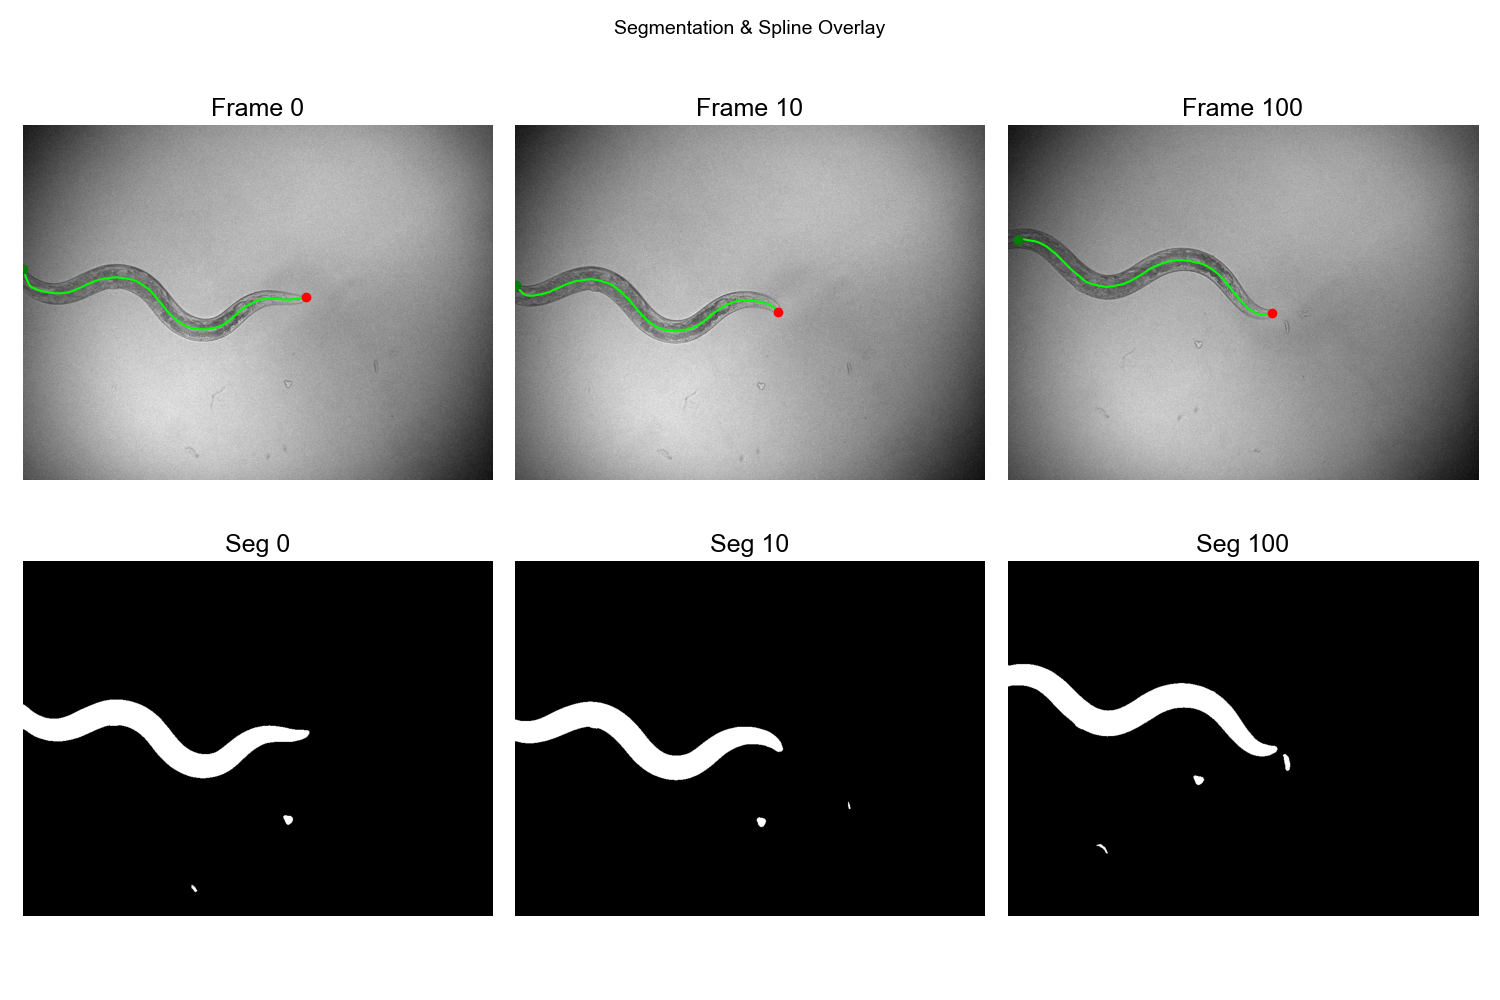

In [40]:
# --- Segmentation + spline overlay for a few example frames ---
example_frames = [0, 10, 100]
img_examples = nir_utils.load_img_nir(INPUT_H5_PTH, frames=example_frames)

fig, axes = plt.subplots(2, len(example_frames), figsize=(5 * len(example_frames), 10))
for j, fidx in enumerate(example_frames):
    # row 1: original + spline overlay
    axes[0, j].imshow(img_examples[j], cmap='gray')
    if splines[fidx] is not None:
        spl = splines[fidx]
        axes[0, j].plot(spl[:, 1], spl[:, 0], '-', color='lime', linewidth=1.5)
        axes[0, j].plot(spl[0, 1], spl[0, 0], 'go', markersize=6)   # head
        axes[0, j].plot(spl[-1, 1], spl[-1, 0], 'ro', markersize=6)  # tail
    axes[0, j].set_title(f'Frame {fidx}')
    axes[0, j].axis('off')

    # row 2: segmentation mask
    axes[1, j].imshow(seg[fidx], cmap='gray')
    axes[1, j].set_title(f'Seg {fidx}')
    axes[1, j].axis('off')

plt.suptitle('Segmentation & Spline Overlay', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# --- Tangent angle profiles for example frames ---
fig, axes = plt.subplots(1, len(example_frames), figsize=(5 * len(example_frames), 4))
for j, fidx in enumerate(example_frames):
    ang = angles[fidx]
    if ang is not None:
        axes[j].plot(ang, color='steelblue')
        axes[j].set_xlabel('Body position (head → tail)')
        axes[j].set_ylabel('Angle (rad)')
    else:
        axes[j].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[j].transAxes)
    axes[j].set_title(f'Frame {fidx}')
plt.suptitle('Tangent Angle Profiles', fontsize=14)
plt.tight_layout()
plt.show()

# --- Angle colormapped on spline for a single frame ---
show_frame = 17
fig, ax = plt.subplots(figsize=(8, 6))
img_show = nir_utils.load_img_nir(INPUT_H5_PTH, frames=show_frame)
ax.imshow(img_show, cmap='gray')
if splines[show_frame] is not None and angles[show_frame] is not None:
    spl = splines[show_frame]
    ang = angles[show_frame]
    # angles has n-1 values; plot at midpoints
    mid_r = 0.5 * (spl[:-1, 0] + spl[1:, 0])
    mid_c = 0.5 * (spl[:-1, 1] + spl[1:, 1])
    sc = ax.scatter(mid_c, mid_r, c=ang, cmap='coolwarm', s=8, zorder=3)
    plt.colorbar(sc, ax=ax, label='Angle (rad)')
ax.set_title(f'Tangent Angle Along Body — Frame {show_frame}')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# --- Eigenworm components ---
fig, ax = plt.subplots(figsize=(10, 5))
body_pos = np.linspace(0, 1, eigenworms.shape[1])
for i in range(eigenworms.shape[0]):
    ax.plot(body_pos, eigenworms[i], label=f'EW{i+1} ({explained_var[i]*100:.1f}%)')
ax.set_xlabel('Body position (head → tail)')
ax.set_ylabel('Weight')
ax.set_title('Eigenworms (PCA Components of Tangent Angle Profiles)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Explained variance ---
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(range(1, len(explained_var) + 1), explained_var * 100, color='steelblue')
ax.set_xlabel('Eigenworm')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Variance Explained by Each Eigenworm')
cum = np.cumsum(explained_var) * 100
for i, c in enumerate(cum):
    ax.text(i + 1, explained_var[i] * 100 + 1, f'{c:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# --- Eigenworm scores over time ---
valid_frame_idx = np.array(result['frame_indices'])[valid_mask]

fig, axes = plt.subplots(pca_scores.shape[1], 1, figsize=(9, 2 * pca_scores.shape[1]), sharex=True)
if pca_scores.shape[1] == 1:
    axes = [axes]
for i in range(pca_scores.shape[1]):
    axes[i].plot(valid_frame_idx, pca_scores[:, i], linewidth=1.5, color='steelblue')
    axes[i].set_ylabel(f'EW{i+1}')
    axes[i].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[-1].set_xlabel('Frame')
plt.suptitle('Eigenworm Scores Over Time', fontsize=14)
plt.tight_layout()
plt.show()

# --- Phase portrait EW1 vs EW2 ---
if pca_scores.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(pca_scores[:, 0], pca_scores[:, 1], c=valid_frame_idx,
                    cmap='viridis', s=3, alpha=0.5)
    ax.set_xlabel('Eigenworm 1')
    ax.set_ylabel('Eigenworm 2')
    ax.set_title('EW1 vs EW2 Phase Portrait')
    plt.colorbar(sc, ax=ax, label='Frame')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Angle kymograph (tangent angle over time) ---
angle_matrix = result['angle_matrix']  # (N_valid, n_angles)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(angle_matrix.T, aspect='auto', cmap='coolwarm',
               extent=[valid_frame_idx[0], valid_frame_idx[-1], 1, 0],
               interpolation='none')
ax.set_xlabel('Frame')
ax.set_ylabel('Body position (head → tail)')
ax.set_title('Tangent Angle Kymograph')
plt.colorbar(im, ax=ax, label='Angle (rad)')
plt.tight_layout()
plt.show()